# Tutorial (sorted units)

This notebook provides a basic tutorial for using c3po on sorted unit data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import pandas as pd

os.environ["CUDA_VISIBLE_DEVICES"] = "9"  # adjust for your machine and availability
import jax

plt.rcParams["svg.fonttype"] = "none"  # to keep fonts editable in Illustrator

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


# Loading Data

Here we will use synthetic data of neurons tuned to a periodic oscillating latent.  


When applying to YOUR DATA, you will need to format into 2 arrays:

`mark_times`: a (n_spikes) array containing the sorted timestamps of spiking events from _all_ units

`mark_ids`: a (n_spikes) array containing the integer neuron_id for each spike. These should be zero-indexed and span (0, n_units-1), where n_units is the total number of sorted units


In [48]:
spiking_df = pd.read_pickle("demo_data/spiking_data.pkl")

mark_times = spiking_df["time"].values
mark_ids = spiking_df["unit"].values
n_units = np.max(mark_ids) + 1

mark_times.shape, mark_ids.shape

((100000,), (100000,))

# Formatting Training Arrays

C3PO models data as a point process, where each event `(x, delta_t)` is the observe spike feature (in this case the neuron_id), and the wait time from the previous event.

To train the model, we segment the data into overlappings samples of `sample_length` events.  In general, when choosing `sample_length` we recommend the following considerations:
- gpu memory capacity: if hit out of memory (OOM) errors, can decrease this to improve
- Multi unit activity rate: the sample is `sample_length * mua_rate` duration on average.  Pick a `sample_length` that allows you to span dynamics of interest. We typically aim for ~2+ seconds in real data, though longer won't hurt if supported by gpu memory

## Data scaling

In general, data should be preprocessed to order ~1 to minimize over/underflow issues.  The `neuron_id` is unitless and not a concern.  For `delta_t` we typically advise scaling to `ms` for most high-density recording data

In [49]:
from c3po.model.util import prep_training_data
scale_unit = "ms"

delta_t = np.diff(mark_times)[None, ...] # delay between each spike event
if scale_unit == "ms":
    delta_t *= 1000
x = mark_ids[1:][None, ...].astype(np.int16) # unit id of each spike event, excluding the first event since it has no delta_t



sample_length = 2000 # number of spike events in each sample
overlap_fraction = .3 # fraction of each sample that overlaps with the next sample
x_train, delta_t_train = prep_training_data(x, delta_t, sample_length)
x_train = x_train[..., None]


mua_rate = np.mean(delta_t)**-1 * 1000
print(f"Average multi-unit activity rate: {mua_rate:.2f} Hz")
print(f"Average sample duration: {(sample_length/mua_rate):.2f} seconds")

3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
Average multi-unit activity rate: 48.73 Hz
Average sample duration: 41.04 seconds


# Build Model

Now we can build a model to embed our data.  In general, C3PO requires relatively few 
parameter choices. We highlight a few relevant ones here:

**Dimensionality**

Unless you have a particular interest otherwise, we recommend using the same dimension for
`latent_dim` and `context_dim`. This determines the dimensionality of the space your data
will end up in. Note that the relavant training features (predicted conditional firing rates)
are linear in this space, allowing for application of PCA after training. For this reason,
we typically recommend selecting a dimensionality a bit higher than the expected 
manifold to allow the model flexibility during training. In practice, we have used 16 dimensions
to find features of interest in a number of brain regions and organisms

**Context Embedding**

While the context can be extracted with any sequential neural network (see 
`src/c3po/model/context.py` for options) we have had good success with a 
[wavenet architecture](https://arxiv.org/abs/1609.03499).  We high light a couple 
relevant parameter choices:

**kernels and dilations**

Wavenet uses a series of dilated, causal convolutions to build a exponentially large
context window with a linear number of parameters. Here, the `layer_kernels` and `layer_dilations`
are the kernel size and dilation factor for each layer of the network respectively.

These set the maximum number of spikes that will feed from the history to infer the context.
We want to choose a size that lets the model look sufficiently far back to tell what's going on
without breaking memory capacity. You can roughly estimate this value as:

`spike_history_size = max(layer_kernels * layer_dilations)` # num spikes

`spike_history_duration = spike_history_size / mua_rate` # context size in seconds

And choose your values accordingly

**Smothing**

For very high-density recordings, the high-frequency (~1kHz) dynamics can obscure slower features
of interest and increase the aamount of training to converge on them. The `smoothing`
parameter gives the option to include a causal smoothing filter of size `smoothing` spikes
over the embedded marks(Z) as the first layer of the context network.  

We have found that in high mua data (> 2 kHz) even a small value (e.g 5, corresponding 
to ~2ms) is sufficient to significantly speed up and stabilize training.  Note that this
will obscure features faster than the `smoothing * mua_rate` timescale, So we recommend
keeping it to a value corresponding to a couple milliseconds

In [50]:
from c3po.model.model import C3PO

# Dimensionality, recommend to be same for both latent and context spaces
latent_dim = 16
context_dim = 16

# Encoder model (waveform (neuron_id) to Z)
encoder_args = dict(
    encoder_model="sorted_spikes",
    n_units=n_units,
    input_format="indices",
)

# Context model (Z to C)
dilations = [
    1,
    2,
    4,
    8,
]
kernels = [8, 8, 16, 16]
dilations = dilations * 2
kernels = kernels * 2
smoothing=1
context_args = dict(
    context_model="wavenet",
    layer_dilations=dilations,
    layer_kernel_size=kernels,
    expanded_dim=64,
    smoothing=smoothing,
    smoothing_decay=1,
    categorical=False,
)
if smoothing >1:
    print(f"Smoothing is enabled with a value of {smoothing}, corresponding to a"
          f"timescale of {smoothing/mua_rate*1000:2f}ms.")
else:
    print("Smoothing is disabled.")

context_window = max([d*k for d, k in zip(dilations, kernels)])
context_time = context_window / mua_rate
print(f"Context window is {context_window} samples, corresponding to a timescale of {context_time*1000:.2f}ms.")


# Rate model (C to hazard function parameters)
# Recommend to NOT change for best interpretability
rate_args = dict(
    rate_model="sharedSpace",
)

# Process model of the conditional Hazard function
# Other options implemented but never found a case where necessary in dense
# recordings with high mua firing rates
process_model = "poisson"

model = C3PO(
    encoder_args,
    context_args,
    rate_args,
    distribution=process_model,
    latent_dim=latent_dim,
    context_dim=context_dim,
    n_neg_samples=8,
    predicted_sequence_length=1,
    return_embeddings_in_call=True,
)

rand_key = jax.random.PRNGKey(0)
params = model.init(jax.random.PRNGKey(0), x_train[:10], delta_t_train[:10], rand_key)
run_model = jax.jit(model.apply)


Smoothing is disabled.
Context window is 128 samples, corresponding to a timescale of 2626.61ms.


# Train Model

We suggest using the included training loop function `train_model` for training your c3po
model.  This loop performs standard gradient descent with a couple notable hyperparameter
schedules:

- `batch_size`: Begins at `initial_batch_size` and reduces by a factor of 2 when updated until it reaches `min_batch_size`
- `n_neg`: the number of negative samples used in the contrastive loss. Intuitively, a larger
  value of `n_neg` make the contrastive problem 'harder' for the model to identify the
  true value. The hyperparameter scheduler will initialize this value to `initial_n_neg`
  and then doble it evbery time training stalls until it reaches `max_n_neg`. At that 
  point, the `batch_size` will reduce and `n_neg` will be reset to the initial low value
  and the process repeated. This provides an 'annealing-like' training schedule

In [53]:
from c3po.model.model import train_model

params, tracked_loss = train_model(
    model,
    params,
    x_train,
    delta_t_train,
    learning_rate = 3e-4, # if outputs end up as all zeros, try a smaller learning rate
    n_epochs=1000, # maximum number of epochs (usually will hit stop criteria long before this)
    initial_batch_size=64,
    buffer_size=8,
    min_batch_size=32,
    max_n_neg=128,
    initial_n_neg=8,
    multi_gpu=False, # If True and multiple GPUs are available, multiple batches can be processed in parallel
)

Epoch 40:  65%|██████▌   | 64/98 [00:00<00:00, 174.53samples/s, batch_size=64, loss=4.78, n_neg=128]


Stalled training, decreasing batch size to 32 and n_neg to 16


Epoch 111:  98%|█████████▊| 96/98 [00:00<00:00, 113.15samples/s, batch_size=32, loss=3.81, n_neg=128]

Stalled training, no further adjustments possible.


# Use model to embed results

Once we've trained our model, the `C3poAnalysis` class provides tools for applying the model
to embed our data, as well as methods to perform a range of analyses including:
- response curves
- power spectrums
- cross-correlations
- feature decoding (e.g. position, head direction)

For complete functionality see methods in `src/c3po/analysis/analysis.py`. Example usage
can be found in the notebooks folder
  


In [54]:
# build c3po analysis object
from c3po.analysis.analysis import C3poAnalysis

model_args = dict(
    encoder_args=encoder_args,
    context_args=context_args,
    rate_args=rate_args,
    distribution=process_model,
    latent_dim=latent_dim,
    context_dim=context_dim,
    n_neg_samples=4, # no longer matters outside of training
)
analysis = C3poAnalysis(
    model=model,
    model_args=model_args,
    params=params,
)



In [55]:
analysis.embed_data(x[...,None], delta_t, first_mark_time=mark_times[0], chunk_size=5000, delta_t_units=scale_unit)
analysis.fit_context_pca()
t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

  0%|          | 0/99999 [00:00<?, ?it/s]

 95%|█████████▌| 95000/99999 [00:01<00:00, 83685.71it/s]


# Accessing results

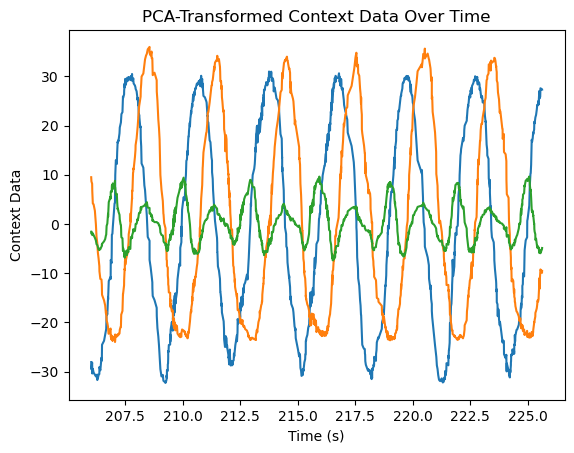

In [56]:
analysis.t # timesamps of the spikes
analysis.c # context data
analysis.z # embedded 'waveform` of each spike
analysis.c_pca # context data after PCA

analysis.t_interp # interpolated timesamps
analysis.c_interp # interpolated context data

import matplotlib.pyplot as plt

ind_plot = slice(10000, 10000 + 1000)
plt.plot(analysis.t[ind_plot], analysis.c_pca[ind_plot][:,:3])
plt.xlabel('Time (s)')
plt.ylabel('Context Data')
plt.title('PCA-Transformed Context Data Over Time')
plt.show()

# To Do: 
## Method to save and load results to filesystem without a sql database